# Python for Data Science Module 1 Practice Notebook

This notebook is the hands-on partner to the **Module 1 Handbook**. We'll practice every idea from the handbook list comprehensions, NumPy, Pandas, File I/O, and plotting on a real dataset: **IPL match data (2008–2016)**, pulled live from a public GitHub CSV.

**How to use this notebook:** run each cell in order. Wherever you see a `# Try it yourself` comment, pause and write the code before looking at the solution in the cell right after it.

**Sections**
1. Setup
2. Python Habits: list comprehensions, lambda, map/filter
3. NumPy arrays & vectorised operations
4. Pandas DataFrames, groupby, merge, pivot
5. File I/O CSV, JSON, Excel
6. Matplotlib & Seaborn — 5 chart types for EDA


## 1. Setup

First, let's install/import everything we need and pull the IPL dataset directly from GitHub.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [38]:
# Load the IPL matches dataset (577 matches, seasons 2008-2016)
url = "https://raw.githubusercontent.com/12345k/IPL-Dataset/master/IPL/data.csv"
ipl = pd.read_csv(url)

print("Shape:", ipl.shape)
ipl.head()

Shape: (577, 18)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


**Always look at your data before touching it.** Let's check column names, data types, and missing values first this is the "inspect real data" habit you should build from day one.

In [39]:
ipl.shape

(577, 18)

In [3]:
ipl.dtypes

id                   int64
season               int64
city                   str
date                   str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
result                 str
dl_applied           int64
winner                 str
win_by_runs          int64
win_by_wickets       int64
player_of_match        str
venue                  str
umpire1                str
umpire2                str
umpire3            float64
dtype: object

In [41]:
ipl.isna().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              0
umpire2              0
umpire3            577
dtype: int64

In [37]:
ipl.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              0
umpire2              0
umpire3            577
dtype: int64

Notice `umpire3` is empty for every single match, and a handful of matches are missing `city`, `winner`, and `player_of_match` (these are usually matches that ended with no result, e.g. rained out). We'll deal with these properly in Section 5 (File I/O) when we save a cleaned version.

## 2. Python Habits: List Comprehensions, Lambda, Map/Filter

*(paired with Handbook Section 2)*

Let's practice these on the `season` and `win_by_runs` columns before we bring in NumPy/Pandas properly.

In [43]:
seasons = ipl["season"].tolist()
seasons

[2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2008,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2009,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,
 2010,

In [45]:
unique_seasons = sorted(list({s for s in seasons}))
unique_seasons

[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

In [5]:
seasons = ipl["season"].tolist()

# List comprehension: unique seasons, sorted
unique_seasons = sorted(list({s for s in seasons}))
print(unique_seasons)

[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


In [6]:
# List comprehension with a condition:
# Which matches were won by more than 50 runs? (store the win margins only)
big_wins = [runs for runs in ipl["win_by_runs"] if runs > 50]
print(f"{len(big_wins)} matches were won by more than 50 runs.")
print(big_wins[:10])

42 matches were won by more than 50 runs.
[140, 66, 65, 105, 75, 92, 92, 78, 78, 53]


In [9]:
# lambda + sorted(): find the 5 biggest win margins (by runs)
top_margins = sorted(ipl["win_by_runs"].tolist(), key=lambda x: x, reverse=True)[:5]
print(top_margins)

[144, 140, 138, 130, 111]


In [10]:
# map() and filter(): convert win_by_runs to a "win category" label
def win_category(runs):
    if runs == 0:
        return "Won by wickets / no result"
    elif runs < 20:
        return "Close win"
    else:
        return "Comfortable win"

categories = list(map(win_category, ipl["win_by_runs"]))
print(categories[:10])

# filter(): keep only the close wins
close_win_flags = list(filter(lambda c: c == "Close win", categories))
print(f"\nNumber of close wins: {len(close_win_flags)}")

['Comfortable win', 'Comfortable win', 'Won by wickets / no result', 'Won by wickets / no result', 'Won by wickets / no result', 'Won by wickets / no result', 'Won by wickets / no result', 'Close win', 'Won by wickets / no result', 'Comfortable win']

Number of close wins: 112


**Try it yourself:** Using a list comprehension, build a list of `True`/`False` values for whether each match had `dl_applied == 1` (Duckworth-Lewis method applied, i.e. a rain-affected match). Then count how many `True` values there are.

In [9]:
# Your turn — write your answer here, then compare with the solution below





In [12]:
# Solution
dl_flags = [x == 1 for x in ipl["dl_applied"]]
print("Rain-affected (DL) matches:", sum(dl_flags))

Rain-affected (DL) matches: 15


## 3. NumPy Arrays & Vectorised Operations

*(paired with Handbook Section 3)*

Let's pull a numeric column out as a NumPy array and practice vectorised operations on it.

In [13]:
win_margins = ipl["win_by_runs"].to_numpy()
print(type(win_margins), win_margins.shape, win_margins.dtype)

<class 'numpy.ndarray'> (577,) int64


In [14]:
# Vectorised operations -- no loops
print("Mean win margin (runs):", win_margins.mean().round(2))
print("Max win margin:", win_margins.max())
print("Matches with a 0-run margin (i.e. won by wickets):", (win_margins == 0).sum())

# np.where: label each match "batting_win" vs "chase_win" vs "no_result"
wickets = ipl["win_by_wickets"].to_numpy()
labels = np.where(win_margins > 0, "Defended total", np.where(wickets > 0, "Chased total", "No result"))
print(labels[:10])

Mean win margin (runs): 13.72
Max win margin: 144
Matches with a 0-run margin (i.e. won by wickets): 316
['Defended total' 'Defended total' 'Chased total' 'Chased total'
 'Chased total' 'Chased total' 'Chased total' 'Defended total'
 'Chased total' 'Defended total']


In [15]:
# A 2D array example: stack win_by_runs and win_by_wickets side by side
combined = np.column_stack([win_margins, wickets])
print(combined.shape)   # (matches, 2)
print(combined[:5])

# Vectorised maths: total "margin points" (a made-up combined score)
margin_points = combined[:, 0] + combined[:, 1] * 6   # pretend a wicket win = 6 "points" per wicket
print(margin_points[:5])

(577, 2)
[[140   0]
 [ 33   0]
 [  0   9]
 [  0   5]
 [  0   5]]
[140  33  54  30  30]


**Try it yourself:** Using NumPy, find how many matches (as a percentage of all matches) had `dl_applied == 1`. Use `.to_numpy()` and vectorised comparison — no loops.

In [16]:
# Your turn





In [17]:
# Solution
dl_arr = ipl["dl_applied"].to_numpy()
pct_dl = (dl_arr == 1).mean() * 100
print(f"{pct_dl:.2f}% of matches were rain-affected (DL applied).")

2.60% of matches were rain-affected (DL applied).


## 4. Pandas — DataFrames, groupby, merge, pivot

*(paired with Handbook Section 4)*

Now the real exploration begins. Let's ask some proper cricket-analytics questions.

In [18]:
# groupby: how many matches has each team won?
wins_by_team = ipl["winner"].value_counts()
wins_by_team.head(10)

winner
Mumbai Indians                 80
Chennai Super Kings            79
Royal Challengers Bangalore    70
Kolkata Knight Riders          68
Rajasthan Royals               63
Kings XI Punjab                63
Delhi Daredevils               56
Sunrisers Hyderabad            34
Deccan Chargers                29
Pune Warriors                  12
Name: count, dtype: int64

In [19]:
# groupby with agg(): average win margin (by runs) per season
season_summary = ipl.groupby("season")["win_by_runs"].agg(["mean", "max", "count"]).round(1)
season_summary

,mean,max,count
season,,,
2008,12.2,140,58
2009,13.4,92,57
2010,16.3,98,60
2011,15.0,111,73
2012,13.0,86,74
2013,16.3,130,76
2014,10.7,93,60
2015,14.4,138,59
2016,11.3,144,60


In [20]:
# groupby on two columns: how did each team perform (wins) each season?
team_season_wins = ipl.groupby(["season", "winner"]).size().reset_index(name="wins")
team_season_wins.head(10)

,season,winner,wins
0,2008,Chennai Super Kings,9
1,2008,Deccan Chargers,2
2,2008,Delhi Daredevils,7
3,2008,Kings XI Punjab,10
4,2008,Kolkata Knight Riders,6
5,2008,Mumbai Indians,7
6,2008,Rajasthan Royals,13
7,2008,Royal Challengers Bangalore,4
8,2009,Chennai Super Kings,8
9,2009,Deccan Chargers,9


**merge**: let's build a small lookup table of team "home cities" and merge it onto the matches table, exactly like the handbook example with `cities`/`df`.

In [21]:
home_city = pd.DataFrame({
    "team": ["Mumbai Indians", "Chennai Super Kings", "Kolkata Knight Riders",
             "Royal Challengers Bangalore", "Delhi Daredevils", "Rajasthan Royals"],
    "home_ground": ["Wankhede Stadium", "MA Chidambaram Stadium", "Eden Gardens",
                     "M Chinnaswamy Stadium", "Feroz Shah Kotla", "Sawai Mansingh Stadium"],
})

merged = ipl.merge(home_city, left_on="winner", right_on="team", how="left")
merged[["season", "winner", "home_ground"]].dropna().head(10)

,season,winner,home_ground
0,2008,Kolkata Knight Riders,Eden Gardens
1,2008,Chennai Super Kings,MA Chidambaram Stadium
2,2008,Delhi Daredevils,Feroz Shah Kotla
3,2008,Royal Challengers Bangalore,M Chinnaswamy Stadium
4,2008,Kolkata Knight Riders,Eden Gardens
5,2008,Rajasthan Royals,Sawai Mansingh Stadium
6,2008,Delhi Daredevils,Feroz Shah Kotla
7,2008,Chennai Super Kings,MA Chidambaram Stadium
8,2008,Rajasthan Royals,Sawai Mansingh Stadium
10,2008,Rajasthan Royals,Sawai Mansingh Stadium


**pivot_table**: how many matches did each team win, broken down by season? (rows = team, columns = season)

In [22]:
pivot = ipl.pivot_table(
    values="id", index="winner", columns="season", aggfunc="count", fill_value=0
)
pivot.head(8)

season,2008,2009,2010,2011,2012,2013,2014,2015,2016
winner,,,,,,,,,
Chennai Super Kings,9,8,9,11,10,12,10,10,0
Deccan Chargers,2,9,8,6,4,0,0,0,0
Delhi Daredevils,7,10,7,4,11,3,2,5,7
Gujarat Lions,0,0,0,0,0,0,0,0,9
Kings XI Punjab,10,7,4,7,8,8,12,3,4
Kochi Tuskers Kerala,0,0,0,6,0,0,0,0,0
Kolkata Knight Riders,6,3,7,8,12,6,11,7,8
Mumbai Indians,7,5,11,10,10,13,7,10,7


**Try it yourself:** Using `groupby`, find which city hosted the most matches overall. (Hint: `ipl.groupby("city")` on the `id` column, sorted descending.)

In [23]:
# Your turn





In [24]:
# Solution
matches_by_city = ipl.groupby("city")["id"].count().sort_values(ascending=False)
matches_by_city.head(5)

city
Mumbai       77
Bangalore    58
Kolkata      54
Delhi        53
Chennai      48
Name: id, dtype: int64

## 5. File I/O — CSV, JSON, Excel

*(paired with Handbook Section 5)*

Let's actually clean this dataset properly, then save it out in all three formats.

In [25]:
# Clean: drop the fully-empty umpire3 column, fill missing city/winner sensibly
ipl_clean = ipl.drop(columns=["umpire3"]).copy()
ipl_clean["city"] = ipl_clean["city"].fillna("Unknown")
ipl_clean["winner"] = ipl_clean["winner"].fillna("No Result")
ipl_clean["player_of_match"] = ipl_clean["player_of_match"].fillna("Not Awarded")

print("Missing values after cleaning:")
print(ipl_clean.isna().sum().sum(), "total missing cells remaining")

Missing values after cleaning:
0 total missing cells remaining


In [29]:
%pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# Save to CSV
ipl_clean.to_csv("ipl_matches_cleaned.csv", index=False)

# Save to JSON (records orient -- a list of row dictionaries)
ipl_clean.to_json("ipl_matches_cleaned.json", orient="records", indent=2)

# Save to Excel
ipl_clean.to_excel("ipl_matches_cleaned.xlsx", index=False, sheet_name="Matches")

print("Saved: ipl_matches_cleaned.csv / .json / .xlsx")

Saved: ipl_matches_cleaned.csv / .json / .xlsx


In [25]:
# Read each format back to confirm it round-trips correctly
back_from_csv = pd.read_csv("ipl_matches_cleaned.csv")
back_from_json = pd.read_json("ipl_matches_cleaned.json")
back_from_excel = pd.read_excel("ipl_matches_cleaned.xlsx")

print("CSV shape:", back_from_csv.shape)
print("JSON shape:", back_from_json.shape)
print("Excel shape:", back_from_excel.shape)

CSV shape: (577, 17)
JSON shape: (577, 17)
Excel shape: (577, 17)


## 6. Matplotlib & Seaborn — 5 Chart Types for EDA

*(paired with Handbook Section 6)*

The syllabus asks for a "visualisation challenge (5 chart types)" — here they are, all built on the cleaned IPL data.

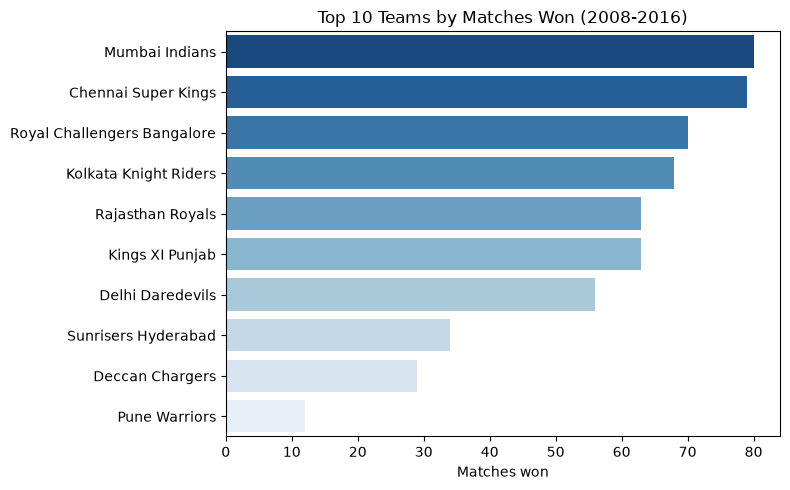

In [31]:
# Chart 1: Bar chart -- matches won per team (top 10)
top_teams = ipl_clean["winner"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_teams.values, y=top_teams.index, hue=top_teams.index, palette="Blues_r", legend=False)
plt.title("Top 10 Teams by Matches Won (2008-2016)")
plt.xlabel("Matches won"); plt.ylabel("")
plt.tight_layout()
plt.show()

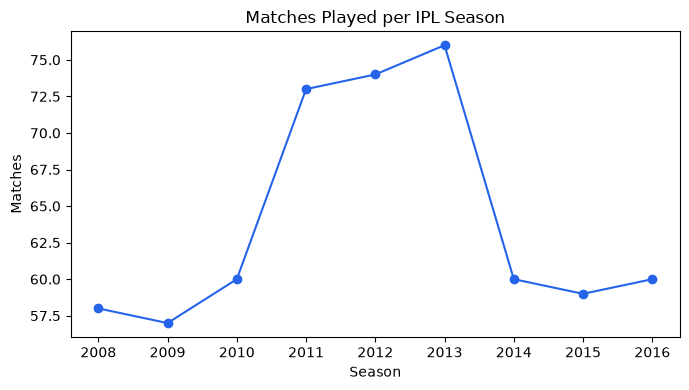

In [32]:
# Chart 2: Line chart -- number of matches played per season
matches_per_season = ipl_clean.groupby("season")["id"].count()

plt.figure(figsize=(7, 4))
plt.plot(matches_per_season.index, matches_per_season.values, marker="o", color="#2563eb")
plt.title("Matches Played per IPL Season")
plt.xlabel("Season"); plt.ylabel("Matches")
plt.tight_layout()
plt.show()

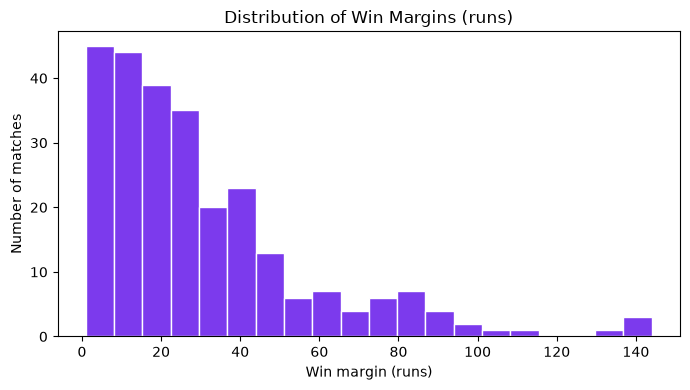

In [33]:
# Chart 3: Histogram -- distribution of win margins (by runs, excluding 0 = wicket wins)
runs_wins = ipl_clean.loc[ipl_clean["win_by_runs"] > 0, "win_by_runs"]

plt.figure(figsize=(7, 4))
plt.hist(runs_wins, bins=20, color="#7c3aed", edgecolor="white")
plt.title("Distribution of Win Margins (runs)")
plt.xlabel("Win margin (runs)"); plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

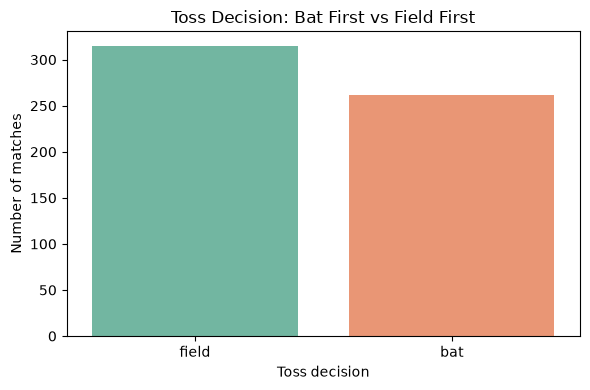

In [34]:
# Chart 4: Countplot -- toss decision (bat vs field) across all matches
plt.figure(figsize=(6, 4))
sns.countplot(data=ipl_clean, x="toss_decision", hue="toss_decision",
              palette="Set2", legend=False)
plt.title("Toss Decision: Bat First vs Field First")
plt.xlabel("Toss decision"); plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

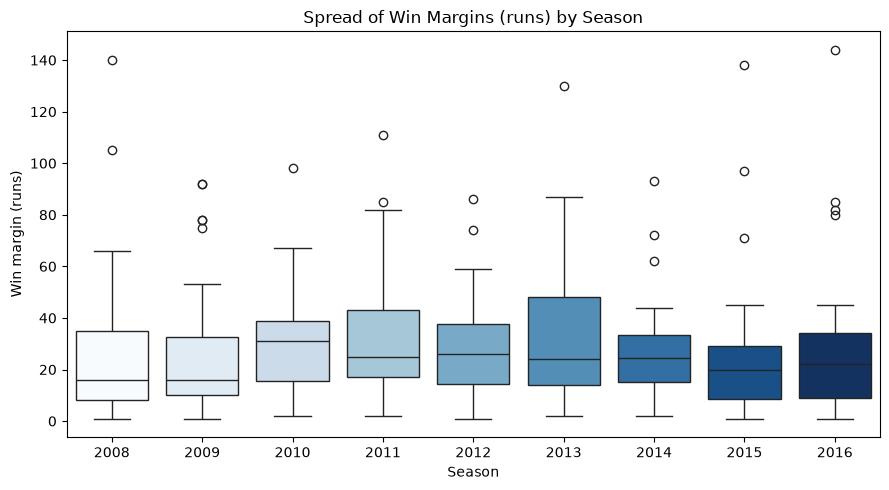

In [35]:
# Chart 5: Boxplot -- win margin (runs) by season, to see how competitiveness changed over time
plt.figure(figsize=(9, 5))
sns.boxplot(data=ipl_clean[ipl_clean["win_by_runs"] > 0], x="season", y="win_by_runs",
            hue="season", palette="Blues", legend=False)
plt.title("Spread of Win Margins (runs) by Season")
plt.xlabel("Season"); plt.ylabel("Win margin (runs)")
plt.tight_layout()
plt.show()

### Quick takeaway

Does winning the toss actually help win the match? Let's check with one more groupby, just for fun.

In [36]:
toss_equals_match_winner = (ipl_clean["toss_winner"] == ipl_clean["winner"]).mean() * 100
print(f"The toss winner also won the match in {toss_equals_match_winner:.1f}% of matches.")

The toss winner also won the match in 50.4% of matches.


---

## You're done with Module 1 practice!

You've now practiced every tool from the handbook on a real dataset. Next: open the **Mini Project — EDA on India's COVID-19 Data**, where you'll repeat this exact workflow (load → clean → explore → visualise → summarise) on a real, messier, government-linked dataset.